In [1]:
from google.colab import drive
drive.mount('/content/drive')

PROJECT   = '/content/drive/MyDrive/KaburAjaDulu'
DATA_DIR  = f'{PROJECT}/data/fine_tuning'
MODEL_DIR = f'{PROJECT}/model_indobert_finetuned'

import os
os.makedirs(MODEL_DIR, exist_ok=True)

Mounted at /content/drive


In [2]:
!pip install transformers datasets torch scikit-learn -q

In [3]:
import pandas as pd

df_train = pd.read_csv(f'{DATA_DIR}/train.csv')
df_val   = pd.read_csv(f'{DATA_DIR}/val.csv')
df_test  = pd.read_csv(f'{DATA_DIR}/test.csv')

In [4]:
from transformers import AutoTokenizer

MODEL_NAME = "indobenchmark/indobert-base-p1"
tokenizer  = AutoTokenizer.from_pretrained(MODEL_NAME)

def tokenize(texts, labels):
    encodings = tokenizer(
        list(texts),
        truncation=True,
        padding=True,
        max_length=128,
        return_tensors="pt"
    )
    return encodings, list(labels)

train_enc, train_labels = tokenize(df_train['clean_text'], df_train['label_num'])
val_enc,   val_labels   = tokenize(df_val['clean_text'],   df_val['label_num'])
test_enc,  test_labels  = tokenize(df_test['clean_text'],  df_test['label_num'])

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:112: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/1.53k [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/2.00 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/229k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

In [5]:
import torch

class SentimentDataset(torch.utils.data.Dataset):
    def __init__(self, encodings, labels):
        self.encodings = encodings
        self.labels    = labels

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        item = {k: v[idx].clone().detach() for k, v in self.encodings.items()}
        item['labels'] = torch.tensor(self.labels[idx], dtype=torch.long)
        return item

train_dataset = SentimentDataset(train_enc, train_labels)
val_dataset   = SentimentDataset(val_enc,   val_labels)
test_dataset  = SentimentDataset(test_enc,  test_labels)

In [6]:
from transformers import AutoModelForSequenceClassification

model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=3
)

[transformers] You passed `num_labels=3` which is incompatible to the `id2label` map of length `5`.


pytorch_model.bin:   0%|          | 0.00/498M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertForSequenceClassification LOAD REPORT from: indobenchmark/indobert-base-p1
Key               | Status  | 
------------------+---------+-
classifier.weight | MISSING | 
classifier.bias   | MISSING | 

Notes:
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


In [7]:
import numpy as np
from sklearn.metrics import accuracy_score, precision_recall_fscore_support

def compute_metrics(pred):
    labels = pred.label_ids
    preds  = pred.predictions.argmax(-1)
    acc = accuracy_score(labels, preds)
    precision, recall, f1, _ = precision_recall_fscore_support(
        labels, preds, average='weighted'
    )
    return {
        'accuracy' : round(acc, 4),
        'precision': round(precision, 4),
        'recall'   : round(recall, 4),
        'f1'       : round(f1, 4)
    }

In [9]:
from transformers import TrainingArguments, Trainer

training_args = TrainingArguments(
    output_dir                  = f'{PROJECT}/results',
    num_train_epochs            = 3,
    per_device_train_batch_size = 16,
    per_device_eval_batch_size  = 32,
    learning_rate               = 2e-5,
    warmup_steps                = 500,
    weight_decay                = 0.01,
    eval_strategy               = 'epoch',
    save_strategy               = 'epoch',
    load_best_model_at_end      = True,
    metric_for_best_model       = 'f1',
    logging_dir                 = f'{PROJECT}/logs',
    logging_steps               = 100,
)

trainer = Trainer(
    model           = model,
    args            = training_args,
    train_dataset   = train_dataset,
    eval_dataset    = val_dataset,
    compute_metrics = compute_metrics,
)

trainer.train()

[transformers] `logging_dir` is deprecated and will be removed in v5.2. Please set `TENSORBOARD_LOGGING_DIR` instead.


Epoch,Training Loss,Validation Loss,Accuracy,Precision,Recall,F1
1,0.348537,0.334060,0.874000,0.874800,0.874000,0.871400
2,0.224284,0.326432,0.890900,0.894500,0.890900,0.891700
3,0.080699,0.471403,0.892500,0.892500,0.892500,0.892200


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

TrainOutput(global_step=3108, training_loss=0.2642217641324764, metrics={'train_runtime': 1078.692, 'train_samples_per_second': 46.089, 'train_steps_per_second': 2.881, 'total_flos': 3270236668941312.0, 'train_loss': 0.2642217641324764, 'epoch': 3.0})

              precision    recall  f1-score   support

     Negatif       0.98      0.96      0.97       257
      Netral       0.88      0.92      0.90        65
     Positif       0.92      0.94      0.93        78

    accuracy                           0.95       400
   macro avg       0.93      0.94      0.93       400
weighted avg       0.95      0.95      0.95       400



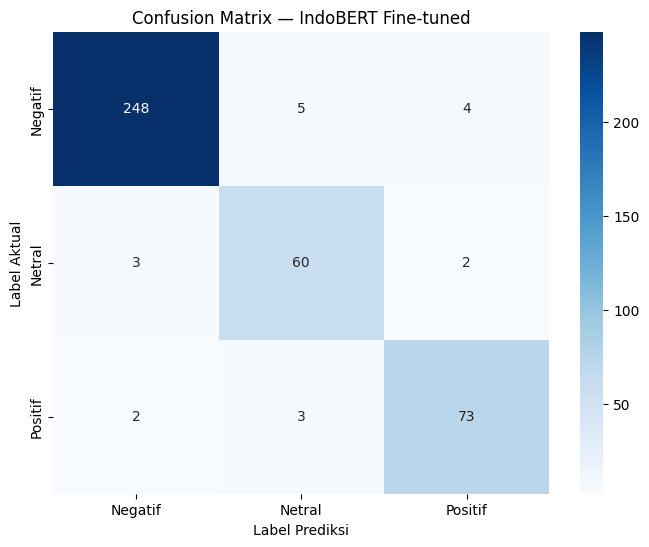

In [10]:
# CELL 9 — Evaluasi final di test set
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt

predictions = trainer.predict(test_dataset)
preds  = predictions.predictions.argmax(-1)
labels = predictions.label_ids

print(classification_report(
    labels, preds,
    target_names=['Negatif', 'Netral', 'Positif']
))

cm = confusion_matrix(labels, preds)
plt.figure(figsize=(8, 6))
sns.heatmap(
    cm, annot=True, fmt='d',
    xticklabels=['Negatif', 'Netral', 'Positif'],
    yticklabels=['Negatif', 'Netral', 'Positif'],
    cmap='Blues'
)
plt.title('Confusion Matrix — IndoBERT Fine-tuned')
plt.ylabel('Label Aktual')
plt.xlabel('Label Prediksi')
plt.savefig(f'{PROJECT}/confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

In [11]:
# CELL 10 — Simpan model
model.save_pretrained(MODEL_DIR)
tokenizer.save_pretrained(MODEL_DIR)
print(f"Model tersimpan di: {MODEL_DIR}")

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Model tersimpan di: /content/drive/MyDrive/KaburAjaDulu/model_indobert_finetuned
